# Bassモデルによるパチンコ参加人口の推定

パチンコ参加人口（各年のプレイヤー総数）の時系列データに対して **Bass拡散モデル** を適用し、
**ModelingToolkit.jl** でモデルを定義、**Turing.jl** でベイズ推定を行う。

### モデルの解釈

パチンコ参加人口は1994年の約2,930万人をピークに減少を続けている。
これを「パチンコ市場からの離脱がBass拡散に従う」と解釈する。

$$\frac{dF}{dt} = (p + qF)(1 - F)$$

- $F(t)$: 時刻 $t$ における市場離脱率（潜在市場のうち離脱した割合）
- $p$: イノベーション係数（外部要因による離脱）
- $q$: イミテーション係数（周囲の離脱に影響された離脱）
- $M$: 潜在市場規模（ピーク時のプレイヤー総数）

**観測モデル**: 時刻 $t$ のパチンコ参加人口は

$$P(t) = M \cdot (1 - F(t))$$

$F(t)$ が増加するにつれ $P(t)$ は減少し、市場縮小のダイナミクスを表現する。

In [162]:
using CSV, DataFrames
using ModelingToolkit, OrdinaryDiffEq
using Turing, MCMCChains
using Plots, StatsPlots
using Random

Random.seed!(42)

TaskLocalRNG()

In [163]:

# Plots 日本語フォント設定
ENV["GKS_ENCODING"] = "utf8"
gr(fontfamily="PlemolJP-Text")

default(
  fontfamily="PlemolJP-Text",
  guidefontsize=11,
  tickfontsize=8,
  legendfontsize=8,
  margin=5Plots.mm,
)

## 1. データの読み込みと前処理

In [164]:
df = CSV.read(raw"..\Pachinko\p-datasets2.csv", DataFrame)

# パチンコ参加人口が存在する行を抽出
col_name = "パチンコ参加人口"
valid = .!ismissing.(df[!, col_name])
years = Int.(df[valid, "年"])
participation = Float64.(df[valid, col_name])  # 単位: 万人

# 時間インデックス（1994年 = 0）
t_start = minimum(years)
t_data = Float64.(years .- t_start)

println("データ期間: $(t_start) - $(maximum(years))")
println("データ点数: $(length(years))")
DataFrame(年=years, 参加人口=participation, t=t_data)

データ期間: 1994 - 2019
データ点数: 26


Row,年,参加人口,t
,Int64,Float64,Float64
1,1994,29300.0,0.0
2,1995,29000.0,1.0
3,1996,27600.0,2.0
4,1997,23100.0,3.0
5,1998,19800.0,4.0
6,1999,18600.0,5.0
7,2000,20200.0,6.0
8,2001,19300.0,7.0
9,2002,21700.0,8.0


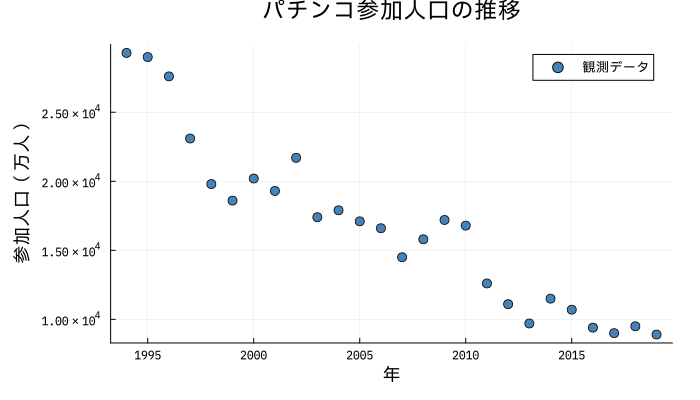

In [165]:
scatter(years, participation,
    xlabel="年", ylabel="参加人口（万人）",
    title="パチンコ参加人口の推移",
    label="観測データ", legend=:topright,
    markersize=5, color=:steelblue,
    size=(700, 400))

## 2. ModelingToolkitによるBassモデルの定義

In [166]:
using ModelingToolkit: t_nounits as t, D_nounits as D

@parameters p_bass q_bass
@variables F(t)

eqs = [D(F) ~ (p_bass + q_bass * F) * (1.0 - F)]

@named bass_sys = ODESystem(eqs, t)
sys = structural_simplify(bass_sys)

println("モデル方程式:")
equations(sys)

モデル方程式:


1-element Vector{Equation}:
 Differential(t, 1)(F(t)) ~ (p_bass + q_bass*F(t))*(1.0 - F(t))

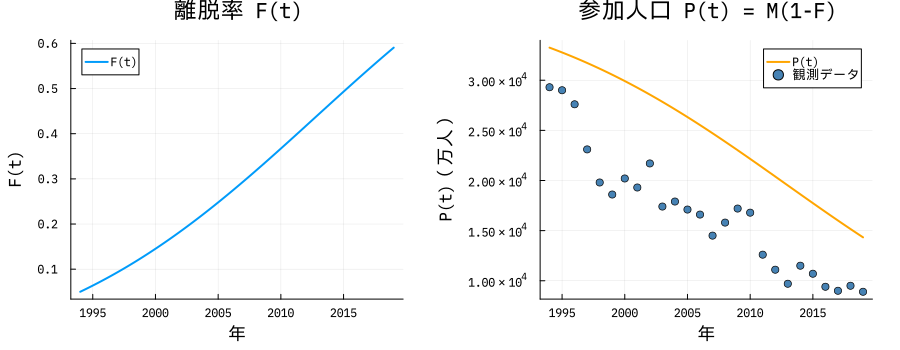

In [167]:
# テスト: パラメータを仮置きしてODEを解く
p_test, q_test, F0_test = 0.01, 0.08, 0.05
M_test = 35000.0

prob_test = ODEProblem(sys,
    [F => F0_test, p_bass => p_test, q_bass => q_test],
    (0.0, 25.0))
sol_test = solve(prob_test, Tsit5(); saveat=0.1)

F_vals = [sol_test.u[i][1] for i in eachindex(sol_test.u)]
P_vals = M_test .* (1.0 .- F_vals)

p1 = plot(sol_test.t .+ t_start, F_vals, xlabel="年", ylabel="F(t)",
    title="離脱率 F(t)", label="F(t)", lw=2)
p2 = plot(sol_test.t .+ t_start, P_vals, xlabel="年", ylabel="P(t)（万人）",
    title="参加人口 P(t) = M(1-F)", label="P(t)", lw=2, color=:orange)
scatter!(p2, years, participation, label="観測データ", color=:steelblue)
plot(p1, p2, layout=(1,2), size=(900, 350))

## 3. Turing.jl によるベイズ推定

パラメータ $(p, q, M, F_0, \sigma)$ の事後分布をNUTSサンプラーで推定する。

- $p \sim \text{Truncated}(\text{Normal}(0.01, 0.05), 0, 0.5)$ — 外部要因による離脱率
- $q \sim \text{Truncated}(\text{Normal}(0.2, 0.2), 0, 2)$ — 口コミ的離脱率
- $M \sim \text{Truncated}(\text{Normal}(35000, 15000), 10000, 100000)$ — 潜在市場規模
- $F_0 \sim \text{Beta}(2, 10)$ （1994年時点ではまだ離脱が少ない想定）
- $\sigma \sim \text{Exponential}(2000)$ — 観測ノイズ

**観測モデル**: $P_{\text{obs}}(t) \sim \text{Normal}(M \cdot (1 - F(t)),\; \sigma)$

In [168]:
# ODE関数（MCMC内での高速化のため関数形式で定義）
function bass_ode!(du, u, params, t)
    Fv = u[1]
    pp, qq = params
    du[1] = (pp + qq * Fv) * (1.0 - Fv)
end

@model function bass_model(y_obs, t_obs)
    # 事前分布
    p ~ truncated(Normal(0.01, 0.05), 0.0001, 0.5)
    q ~ truncated(Normal(0.2, 0.2), 0.001, 2.0)
    M ~ truncated(Normal(35000.0, 15000.0), 10000.0, 100000.0)
    F0 ~ Beta(2.0, 10.0)
    σ ~ Exponential(2000.0)

    # ODE を解く
    prob = ODEProblem(bass_ode!, [F0], (0.0, maximum(t_obs) + 0.1), [p, q])
    sol = solve(prob, Tsit5(); saveat=t_obs, abstol=1e-8, reltol=1e-8)

    if sol.retcode != ReturnCode.Success
        Turing.@addlogprob! -Inf
        return
    end

    # 尤度: P(t) = M * (1 - F(t))
    for i in eachindex(y_obs)
        F_t = sol.u[i][1]
        P_pred = M * (1.0 - F_t)
        y_obs[i] ~ Normal(P_pred, σ)
    end
end

println("モデル定義完了")

モデル定義完了


In [169]:
# MCMC サンプリング（NUTS）
model = bass_model(participation, t_data)
chain = sample(model, NUTS(0.65), MCMCSerial(), 2000, 2; progress=true)
println("サンプリング完了")

┌ Info: Found initial step size
└   ϵ = 3.0517578125e-6
Sampling (Chain 1 of 2): 100%|██████████████████████████| Time: 0:00:13
┌ Info: Found initial step size
└   ϵ = 4.8828125e-5
Sampling (Chain 2 of 2): 100%|██████████████████████████| Time: 0:00:09


サンプリング完了


## 4. 推定結果の確認

In [170]:
display(chain)
println("\n--- 要約統計量 ---")
display(summarystats(chain))

Chains MCMC chain (2000×19×2 Array{Float64, 3}):

Iterations        = 1001:1:3000
Number of chains  = 2
Samples per chain = 2000
Wall duration     = 25.07 seconds
Compute duration  = 25.0 seconds
parameters        = p, q, M, F0, σ
internals         = n_steps, is_accept, acceptance_rate, log_density, hamiltonian_energy, hamiltonian_energy_error, max_hamiltonian_energy_error, tree_depth, numerical_error, step_size, nom_step_size, logprior, loglikelihood, logjoint

Use `describe(chains)` for summary statistics and quantiles.



--- 要約統計量 ---


Summary Statistics

  parameters         mean         std       mcse    ess_bulk    ess_tail       ⋯
      Symbol      Float64     Float64    Float64     Float64     Float64   Flo ⋯

           p       0.0350      0.0090     0.0006    315.2582    305.8620    1. ⋯
           q       0.0245      0.0186     0.0009    464.2744    431.7300    1. ⋯
           M   33974.5839   4731.0325   247.4207    503.3964    269.4968    1. ⋯
          F0       0.1772      0.0980     0.0050    457.4026    255.3108    1. ⋯
           σ    1930.2636    301.3099     8.0272   1644.8308   1283.3847    1. ⋯

                                                               2 columns omitted


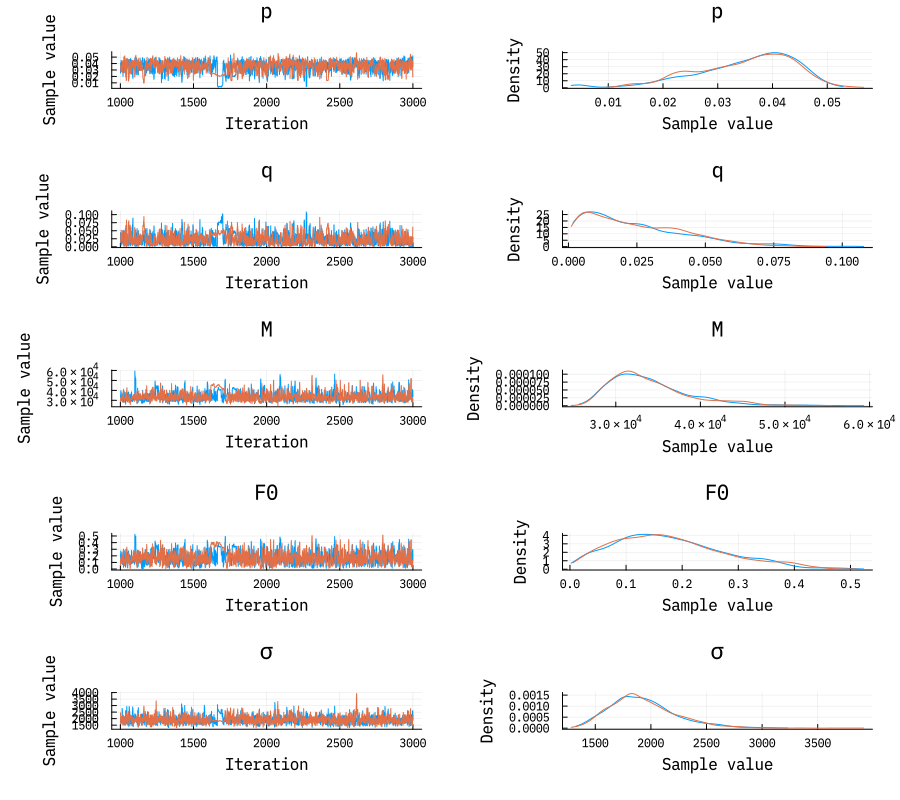

In [171]:
plot(chain[[:p, :q, :M, :F0, :σ]], size=(900, 800))

In [172]:
# パラメータの事後分布を抽出
p_post = vec(chain[:p])
q_post = vec(chain[:q])
M_post = vec(chain[:M])
F0_post = vec(chain[:F0])

println("p  (イノベーション係数): mean=$(round(mean(p_post), sigdigits=4)), std=$(round(std(p_post), sigdigits=4))")
println("q  (イミテーション係数): mean=$(round(mean(q_post), sigdigits=4)), std=$(round(std(q_post), sigdigits=4))")
println("M  (潜在市場規模):       mean=$(round(mean(M_post), sigdigits=6)), std=$(round(std(M_post), sigdigits=4))")
println("F0 (初期離脱率):         mean=$(round(mean(F0_post), sigdigits=4)), std=$(round(std(F0_post), sigdigits=4))")
println("q/p比:                   $(round(mean(q_post)/mean(p_post), sigdigits=4))")

p  (イノベーション係数): mean=0.03504, std=0.009046
q  (イミテーション係数): mean=0.02445, std=0.01861
M  (潜在市場規模):       mean=33974.6, std=4731.0
F0 (初期離脱率):         mean=0.1772, std=0.09805
q/p比:                   0.6978


## 5. 事後予測プロット

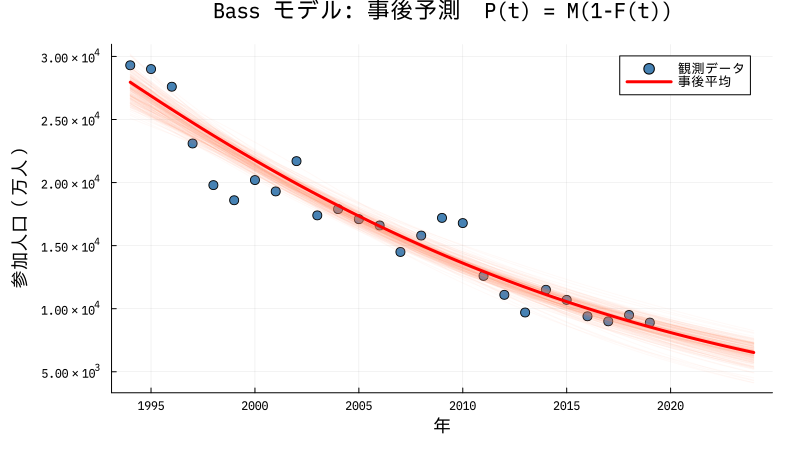

In [173]:
# 事後予測: サンプルからランダムに200本のカーブを描画
t_fine = collect(0.0:0.1:30.0)
n_samples = min(200, length(p_post))
idx = rand(1:length(p_post), n_samples)

plt_pred = scatter(years, participation,
    xlabel="年", ylabel="参加人口（万人）",
    title="Bass モデル: 事後予測  P(t) = M(1-F(t))",
    label="観測データ", color=:steelblue,
    markersize=5, legend=:topright, size=(800, 450))

for k in idx
    prob_k = ODEProblem(bass_ode!, [F0_post[k]], (0.0, 30.0), [p_post[k], q_post[k]])
    sol_k = solve(prob_k, Tsit5(); saveat=t_fine)
    if sol_k.retcode == ReturnCode.Success
        F_k = [sol_k.u[j][1] for j in eachindex(sol_k.u)]
        P_k = M_post[k] .* (1.0 .- F_k)
        plot!(plt_pred, t_fine .+ t_start, P_k,
            alpha=0.05, color=:coral, label=nothing)
    end
end

# 事後平均カーブ
p_mean = mean(p_post)
q_mean = mean(q_post)
M_mean = mean(M_post)
F0_mean = mean(F0_post)

prob_mean = ODEProblem(bass_ode!, [F0_mean], (0.0, 30.0), [p_mean, q_mean])
sol_mean = solve(prob_mean, Tsit5(); saveat=t_fine)
F_mean_vals = [sol_mean.u[j][1] for j in eachindex(sol_mean.u)]
P_mean_vals = M_mean .* (1.0 .- F_mean_vals)

plot!(plt_pred, t_fine .+ t_start, P_mean_vals,
    lw=3, color=:red, label="事後平均")

plt_pred

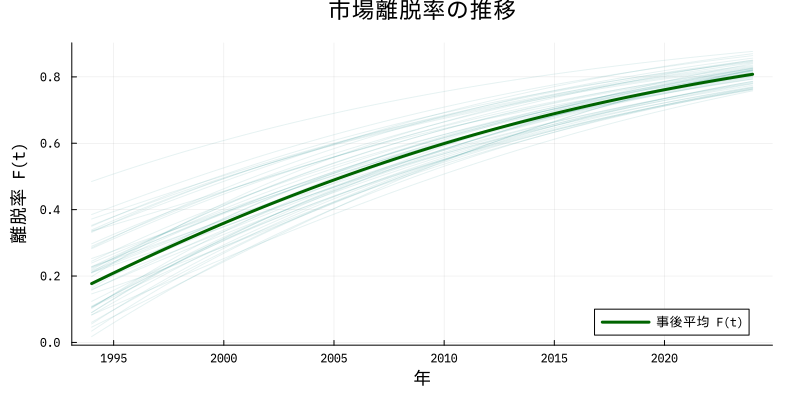

In [174]:
# 浸透率（離脱率）F(t) の推移
plt_F = plot(xlabel="年", ylabel="離脱率 F(t)",
    title="市場離脱率の推移", size=(800, 400), legend=:bottomright)

for k in idx[1:50]
    prob_k = ODEProblem(bass_ode!, [F0_post[k]], (0.0, 30.0), [p_post[k], q_post[k]])
    sol_k = solve(prob_k, Tsit5(); saveat=t_fine)
    if sol_k.retcode == ReturnCode.Success
        F_k = [sol_k.u[j][1] for j in eachindex(sol_k.u)]
        plot!(plt_F, t_fine .+ t_start, F_k,
            alpha=0.1, color=:teal, label=nothing)
    end
end

plot!(plt_F, t_fine .+ t_start, F_mean_vals,
    lw=3, color=:darkgreen, label="事後平均 F(t)")

plt_F

In [175]:
# 将来予測
for target_year in [2024, 2025, 2030]
    t_target = Float64(target_year - t_start)
    preds = Float64[]
    for k in eachindex(p_post)
        prob_k = ODEProblem(bass_ode!, [F0_post[k]], (0.0, t_target + 0.1), [p_post[k], q_post[k]])
        sol_k = solve(prob_k, Tsit5(); saveat=[t_target])
        if sol_k.retcode == ReturnCode.Success && length(sol_k.u) > 0
            F_k = sol_k.u[end][1]
            P_k = M_post[k] * (1.0 - F_k)
            push!(preds, P_k)
        end
    end
    println("$(target_year)年 予測参加人口: $(round(mean(preds), digits=0))万人 ",
            "[95% CI: $(round(quantile(preds, 0.025), digits=0)) - $(round(quantile(preds, 0.975), digits=0))]")
end

2024年 予測参加人口: 6467.0万人 [95% CI: 5083.0 - 7702.0]
2025年 予測参加人口: 6125.0万人 [95% CI: 4722.0 - 7376.0]
2030年 予測参加人口: 4657.0万人 [95% CI: 3240.0 - 5912.0]


## 6. ホール比例モデル

潜在市場規模をホール数に比例させるモデル。M(t) の**形状**をデータで固定し、**スケールだけ**を推定する:

$$M(t) = M_0 \cdot \left(\frac{\text{Halls}(t)}{\text{Halls}(0)}\right)^\alpha$$

- $M_0$: 1994年時点の潜在市場規模
- $\alpha$: ホール数弾力性（α=1 で線形比例、α>1 で超線形）

これにより:
1. M(t) はホール減とともに必ず縮小（直感に合致）
2. F(t) はホール減では説明できない「追加的な離脱」を捕捉

In [176]:
# モデル4: ホール比例 M(t) + 標準Bass ODE
# M(t) = M0 * (Halls(t)/Halls(0))^α
# P(t) = M(t) * (1 - F(t))

halls_ratio = halls_data ./ halls_data[1]  # Halls(t)/Halls(1994)

println("ホール数比率 Halls(t)/Halls(1994):")
println("  1994: $(round(halls_ratio[1], digits=3))")
println("  2000: $(round(halls_ratio[7], digits=3))")
println("  2010: $(round(halls_ratio[17], digits=3))")
println("  2019: $(round(halls_ratio[end], digits=3))")

@model function bass_model_halls(y_obs, t_obs, halls_ratio)
    p ~ truncated(Normal(0.01, 0.05), 0.0001, 0.5)
    q ~ truncated(Normal(0.2, 0.2), 0.001, 2.0)
    M0 ~ truncated(Normal(35000.0, 15000.0), 10000.0, 150000.0)
    F0 ~ Beta(2.0, 10.0)
    σ ~ Exponential(2000.0)
    α ~ truncated(Normal(1.0, 0.5), 0.01, 5.0)  # 弾力性

    prob = ODEProblem(bass_ode!, [F0], (0.0, maximum(t_obs) + 0.1), [p, q])
    sol = solve(prob, Tsit5(); saveat=t_obs, abstol=1e-8, reltol=1e-8)

    if sol.retcode != ReturnCode.Success
        Turing.@addlogprob! -Inf
        return
    end

    for i in eachindex(y_obs)
        F_t = sol.u[i][1]
        M_t = M0 * halls_ratio[i]^α
        P_pred = M_t * (1.0 - F_t)
        y_obs[i] ~ Normal(P_pred, σ)
    end
end

println("ホール比例モデル定義完了")

LoadError: UndefVarError: `halls_data` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [ ]:
model_halls = bass_model_halls(participation, t_data, halls_ratio)
chain_halls = sample(model_halls, NUTS(0.65), MCMCSerial(), 2000, 2; progress=true)
println("ホール比例モデル サンプリング完了")

In [ ]:
display(summarystats(chain_halls))

p_post4 = vec(chain_halls[:p])
q_post4 = vec(chain_halls[:q])
M0_post = vec(chain_halls[:M0])
F0_post4 = vec(chain_halls[:F0])
σ_post4 = vec(chain_halls[:σ])
α_post = vec(chain_halls[:α])

println("\n--- パラメータ ---")
println("p  : $(round(mean(p_post4), sigdigits=4)) ± $(round(std(p_post4), sigdigits=3))")
println("q  : $(round(mean(q_post4), sigdigits=4)) ± $(round(std(q_post4), sigdigits=3))")
println("M0 : $(round(mean(M0_post), sigdigits=6)) ± $(round(std(M0_post), sigdigits=4))")
println("F0 : $(round(mean(F0_post4), sigdigits=4)) ± $(round(std(F0_post4), sigdigits=3))")
println("α  : $(round(mean(α_post), sigdigits=4)) ± $(round(std(α_post), sigdigits=3))")
println("\n--- 解釈 ---")
println("α ≈ 1.0 → Mはホール数に線形比例")
println("α > 1.0 → ホール減が市場を超線形に縮小")
println("α < 1.0 → ホール減の影響は緩やか")

In [ ]:
plot(chain_halls[[:p, :q, :M0, :F0, :α, :σ]], size=(900, 900))

In [ ]:
# M(t) の推移
M_t_halls = zeros(length(years), length(M0_post))
for k in eachindex(M0_post)
    for i in eachindex(years)
        M_t_halls[i, k] = M0_post[k] * halls_ratio[i]^α_post[k]
    end
end
M_t_halls_mean = vec(mean(M_t_halls, dims=2))
M_t_halls_lo = [quantile(M_t_halls[i, :], 0.025) for i in eachindex(years)]
M_t_halls_hi = [quantile(M_t_halls[i, :], 0.975) for i in eachindex(years)]

plt_M = plot(years, M_t_halls_mean,
    ribbon=(M_t_halls_mean .- M_t_halls_lo, M_t_halls_hi .- M_t_halls_mean),
    xlabel="年", ylabel="M(t)",
    title="ホール比例モデル: 潜在市場規模 M(t) = M₀·(H/H₀)^α",
    label="事後平均 (95% CI)", lw=2, color=:darkviolet, fillalpha=0.2,
    size=(800, 400), legend=:topright)
hline!([mean(M_post)], ls=:dash, color=:gray, label="定数Mモデル")

plt_M

In [ ]:
# 事後予測プロット
n_draw4 = min(200, length(p_post4))
idx4 = rand(1:length(p_post4), n_draw4)

plt_halls = scatter(years, participation,
    xlabel="年", ylabel="参加人口（万人）",
    title="ホール比例モデル: P(t) = M₀·(H/H₀)^α·(1-F(t))",
    label="観測データ", color=:steelblue,
    markersize=5, legend=:topright, size=(800, 450))

for k in idx4
    prob_k = ODEProblem(bass_ode!, [F0_post4[k]], (0.0, maximum(t_data) + 0.1),
        [p_post4[k], q_post4[k]])
    sol_k = solve(prob_k, Tsit5(); saveat=t_data)
    if sol_k.retcode == ReturnCode.Success
        P_k = [M_t_halls[i, k] * (1.0 - sol_k.u[i][1]) for i in eachindex(years)]
        plot!(plt_halls, years, P_k, alpha=0.05, color=:coral, label=nothing)
    end
end

# 事後平均
prob_s = ODEProblem(bass_ode!, [mean(F0_post4)], (0.0, maximum(t_data) + 0.1),
    [mean(p_post4), mean(q_post4)])
sol_s = solve(prob_s, Tsit5(); saveat=t_data)
P_halls_mean = [M_t_halls_mean[i] * (1.0 - sol_s.u[i][1]) for i in eachindex(years)]
plot!(plt_halls, years, P_halls_mean, lw=3, color=:red, label="ホール比例モデル")

# 定数Mモデル
prob_b = ODEProblem(bass_ode!, [mean(F0_post)], (0.0, maximum(t_data) + 0.1),
    [mean(p_post), mean(q_post)])
sol_b = solve(prob_b, Tsit5(); saveat=t_data)
P_b = mean(M_post) .* (1.0 .- [sol_b.u[j][1] for j in eachindex(sol_b.u)])
plot!(plt_halls, years, P_b, lw=2, ls=:dash, color=:gray, label="定数Mモデル")

plt_halls

In [ ]:
# 寄与分解（ホール比例モデル）
F_traj4 = [sol_s.u[i][1] for i in eachindex(years)]
ratio_M4 = M_t_halls_mean ./ M_t_halls_mean[1]
ratio_F4 = (1.0 .- F_traj4) ./ (1.0 - F_traj4[1])
ratio_P4 = ratio_M4 .* ratio_F4
actual_ratio = participation ./ participation[1]

plt_dec = plot(years, ratio_M4, lw=2, label="M(t)/M(0) — ホール減による市場縮小",
    color=:darkviolet, ls=:dash, size=(800, 450))
plot!(plt_dec, years, ratio_F4, lw=2, label="(1-F)/(1-F₀) — Bass離脱の効果",
    color=:teal)
plot!(plt_dec, years, ratio_P4, lw=2, label="予測 P(t)/P(0)", color=:red)
scatter!(plt_dec, years, actual_ratio, label="実測 P(t)/P(0)",
    color=:steelblue, markersize=4)
hline!([1.0], ls=:dot, color=:gray, label=nothing)
plot!(plt_dec, xlabel="年", ylabel="1994年基準の比率",
    title="寄与分解: ホール縮小 M↓ vs Bass離脱 F↑",
    legend=:right)

plt_dec

In [ ]:
# モデル比較: 定数M vs ホール比例
function loglik_const_M(participation, t_data, p, q, M, F0, σ)
    prob = ODEProblem(bass_ode!, [F0], (0.0, maximum(t_data) + 0.1), [p, q])
    sol = solve(prob, Tsit5(); saveat=t_data, abstol=1e-8, reltol=1e-8)
    sol.retcode != ReturnCode.Success && return -Inf
    ll = 0.0
    for i in eachindex(participation)
        ll += logpdf(Normal(M * (1.0 - sol.u[i][1]), σ), participation[i])
    end
    return ll
end

function loglik_halls(participation, t_data, p, q, M0, F0, α, σ, halls_ratio)
    prob = ODEProblem(bass_ode!, [F0], (0.0, maximum(t_data) + 0.1), [p, q])
    sol = solve(prob, Tsit5(); saveat=t_data, abstol=1e-8, reltol=1e-8)
    sol.retcode != ReturnCode.Success && return -Inf
    ll = 0.0
    for i in eachindex(participation)
        M_t = M0 * halls_ratio[i]^α
        ll += logpdf(Normal(M_t * (1.0 - sol.u[i][1]), σ), participation[i])
    end
    return ll
end

σ_post_c = vec(chain[:σ])
ll_const = mean(loglik_const_M.(Ref(participation), Ref(t_data),
    p_post, q_post, M_post, F0_post, σ_post_c))
ll_halls = mean(loglik_halls.(Ref(participation), Ref(t_data),
    p_post4, q_post4, M0_post, F0_post4, α_post, σ_post4, Ref(halls_ratio)))

println("=== モデル比較 ===")
println("(1) 定数M        — 平均対数尤度: $(round(ll_const, digits=2))  (パラメータ: 5)")
println("(2) ホール比例M(t) — 平均対数尤度: $(round(ll_halls, digits=2))  (パラメータ: 6)")
println("\n改善: $(round(ll_halls - ll_const, digits=2))")


## 7. 人口減少の影響を分離する

モデル4を拡張し、人口比も加えてホールと人口の寄与を分離する:

$$M(t) = M_0 \cdot \left(\frac{\text{Shops}(t)}{\text{Shops}_0}\right)^{\alpha_s} \cdot \left(\frac{\text{Pop}(t)}{\text{Pop}_0}\right)^{\alpha_p}$$

| 変数 | 1994→2019変動幅 | 備考 |
|------|-----------------|------|
| 総人口 | 2.25% | 2008年ピーク後微減 |
| ホール数 | 47.5% | 一貫して減少 |

人口変化は極めて小さいため、$\alpha_p$ の推定精度は低い可能性がある。

In [ ]:
# モデル5: ホール + 人口 比例 M(t)
pop_ratio = pop_data ./ pop_data[1]   # Pop(t)/Pop(1994)
# halls_ratio は既に定義済み

println("変動幅確認:")
println("  Pop  ratio: $(round(minimum(pop_ratio),digits=4)) - $(round(maximum(pop_ratio),digits=4))")
println("  Hall ratio: $(round(minimum(halls_ratio),digits=4)) - $(round(maximum(halls_ratio),digits=4))")

@model function bass_model_halls_pop(y_obs, t_obs, halls_ratio, pop_ratio)
    p ~ truncated(Normal(0.01, 0.05), 0.0001, 0.5)
    q ~ truncated(Normal(0.2, 0.2), 0.001, 2.0)
    M0 ~ truncated(Normal(35000.0, 15000.0), 10000.0, 150000.0)
    F0 ~ Beta(2.0, 10.0)
    σ ~ Exponential(2000.0)
    α_h ~ truncated(Normal(1.0, 0.5), 0.01, 5.0)    # ホール弾力性
    α_p ~ Normal(1.0, 2.0)                           # 人口弾力性（広い事前分布）

    prob = ODEProblem(bass_ode!, [F0], (0.0, maximum(t_obs) + 0.1), [p, q])
    sol = solve(prob, Tsit5(); saveat=t_obs, abstol=1e-8, reltol=1e-8)
    if sol.retcode != ReturnCode.Success
        Turing.@addlogprob! -Inf; return
    end

    for i in eachindex(y_obs)
        F_t = sol.u[i][1]
        M_t = M0 * halls_ratio[i]^α_h * pop_ratio[i]^α_p
        P_pred = M_t * (1.0 - F_t)
        y_obs[i] ~ Normal(P_pred, σ)
    end
end

println("モデル5（ホール+人口）定義完了")

In [ ]:
model_sp = bass_model_halls_pop(participation, t_data, halls_ratio, pop_ratio)
chain_sp = sample(model_sp, NUTS(0.65), MCMCSerial(), 2000, 2; progress=true)
println("モデル5 サンプリング完了")

In [ ]:
display(summarystats(chain_sp))

p_post5 = vec(chain_sp[:p])
q_post5 = vec(chain_sp[:q])
M0_post5 = vec(chain_sp[:M0])
F0_post5 = vec(chain_sp[:F0])
σ_post5 = vec(chain_sp[:σ])
αh_post = vec(chain_sp[:α_h])
αp_post = vec(chain_sp[:α_p])

println("\n--- パラメータ ---")
println("p   : $(round(mean(p_post5), sigdigits=4)) ± $(round(std(p_post5), sigdigits=3))")
println("q   : $(round(mean(q_post5), sigdigits=4)) ± $(round(std(q_post5), sigdigits=3))")
println("M0  : $(round(mean(M0_post5), sigdigits=6)) ± $(round(std(M0_post5), sigdigits=4))")
println("F0  : $(round(mean(F0_post5), sigdigits=4)) ± $(round(std(F0_post5), sigdigits=3))")
println("α_h : $(round(mean(αh_post), sigdigits=4)) ± $(round(std(αh_post), sigdigits=3))  ← ホール弾力性")
println("α_p : $(round(mean(αp_post), sigdigits=4)) ± $(round(std(αp_post), sigdigits=3))  ← 人口弾力性")

# α_p の 95% 信用区間
αp_lo, αp_hi = quantile(αp_post, 0.025), quantile(αp_post, 0.975)
println("\nα_p 95%CI: [$(round(αp_lo, digits=2)), $(round(αp_hi, digits=2))]")
if αp_lo < 0 && αp_hi > 0
    println("→ 0 を含むため、人口変化の効果は統計的に不明瞭")
else
    println("→ 0 を含まない — 人口変化の効果は検出された")
end

In [ ]:
# 人口とホールの寄与を分離
αh_mean = mean(αh_post)
αp_mean = mean(αp_post)
M0_mean5 = mean(M0_post5)

# 各要因の寄与（1994年基準）
contrib_halls = halls_ratio .^ αh_mean         # ホールのみの効果
contrib_pop = pop_ratio .^ αp_mean              # 人口のみの効果
contrib_total_M = contrib_halls .* contrib_pop   # M(t)/M0 全体

# F(t) の効果
prob5 = ODEProblem(bass_ode!, [mean(F0_post5)], (0.0, maximum(t_data) + 0.1),
    [mean(p_post5), mean(q_post5)])
sol5 = solve(prob5, Tsit5(); saveat=t_data)
F_traj5 = [sol5.u[i][1] for i in eachindex(years)]
contrib_F = (1.0 .- F_traj5) ./ (1.0 - F_traj5[1])

println("=== 各要因の寄与（1994年 = 1.0）===")
println(lpad("年",6), lpad("ホール効果",10), lpad("人口効果",10), lpad("M比",10), lpad("F効果",10), lpad("P比",10), lpad("実測比",10))
actual_ratio = participation ./ participation[1]
for i in [1, 4, 7, 10, 14, 17, 20, 23, 26]
    predicted = contrib_total_M[i] * contrib_F[i]
    println(lpad(years[i],6),
        lpad(round(contrib_halls[i], digits=3),10),
        lpad(round(contrib_pop[i], digits=3),10),
        lpad(round(contrib_total_M[i], digits=3),10),
        lpad(round(contrib_F[i], digits=3),10),
        lpad(round(predicted, digits=3),10),
        lpad(round(actual_ratio[i], digits=3),10))
end

In [ ]:
# 3要因分解の可視化
plt3 = plot(years, contrib_halls, lw=2, ls=:dash, color=:brown,
    label="ホール効果 (Halls/Halls₀)^α_h", size=(800, 500))
plot!(plt3, years, contrib_pop, lw=2, ls=:dashdot, color=:purple,
    label="人口効果 (Pop/Pop₀)^α_p")
plot!(plt3, years, contrib_total_M, lw=2, ls=:dash, color=:darkviolet,
    label="M(t)/M₀ 合計")
plot!(plt3, years, contrib_F, lw=2, color=:teal,
    label="Bass離脱 (1-F)/(1-F₀)")
plot!(plt3, years, contrib_total_M .* contrib_F, lw=2, color=:red,
    label="予測 P/P₀")
scatter!(plt3, years, actual_ratio, color=:steelblue, markersize=4,
    label="実測 P/P₀")
hline!([1.0], ls=:dot, color=:gray, label=nothing)
plot!(plt3, xlabel="年", ylabel="1994年基準の比率",
    title="3要因分解: ホール減 × 人口変化 × Bass離脱",
    legend=:right)

plt3

In [ ]:
# 2019年時点での寄与率（対数分解）
log_total = log(actual_ratio[end])
log_halls = log(contrib_halls[end])
log_pop = log(contrib_pop[end])
log_F = log(contrib_F[end])
log_model = log_halls + log_pop + log_F

println("=== 2019年の参加人口減少の要因分解 ===")
println("実測: P(2019)/P(1994) = $(round(actual_ratio[end], digits=3)) （$(round((1-actual_ratio[end])*100, digits=1))%減）")
println()
println("対数分解（加法的）:")
println("  ホール効果  : $(round(log_halls, digits=3))  → 寄与率 $(round(log_halls/log_model*100, digits=1))%")
println("  人口効果  : $(round(log_pop, digits=3))  → 寄与率 $(round(log_pop/log_model*100, digits=1))%")
println("  Bass離脱  : $(round(log_F, digits=3))  → 寄与率 $(round(log_F/log_model*100, digits=1))%")
println("  合計      : $(round(log_model, digits=3))")
println()
println("--- 感度分析: 人口がさらに減少した場合 ---")
for pop_decline in [0.95, 0.90, 0.85, 0.80]
    m_effect = pop_decline ^ αp_mean
    println("  人口$(round(Int, (1-pop_decline)*100))%減 → M への影響: $(round(m_effect, digits=3))  （M が$(round((1-m_effect)*100, digits=1))%縮小）")
end

In [ ]:
# 最終モデル比較
function loglik_sp(participation, t_data, p, q, M0, F0, αh, αp, σ, halls_ratio, pop_ratio)
    prob = ODEProblem(bass_ode!, [F0], (0.0, maximum(t_data) + 0.1), [p, q])
    sol = solve(prob, Tsit5(); saveat=t_data, abstol=1e-8, reltol=1e-8)
    sol.retcode != ReturnCode.Success && return -Inf
    ll = 0.0
    for i in eachindex(participation)
        M_t = M0 * halls_ratio[i]^αh * pop_ratio[i]^αp
        ll += logpdf(Normal(M_t * (1.0 - sol.u[i][1]), σ), participation[i])
    end
    return ll
end

ll_sp = mean(loglik_sp.(Ref(participation), Ref(t_data),
    p_post5, q_post5, M0_post5, F0_post5, αh_post, αp_post, σ_post5,
    Ref(halls_ratio), Ref(pop_ratio)))

println("=== 最終モデル比較 ===")
println("(1) 定数M           — 平均対数尤度: $(round(ll_const, digits=2))  (パラメータ: 5)")
println("(2) ホール比例M(t)   — 平均対数尤度: $(round(ll_halls, digits=2))  (パラメータ: 6)")
println("(3) ホール+人口M(t) — 平均対数尤度: $(round(ll_sp, digits=2))  (パラメータ: 7)")
println("\n(1)→(2)の改善: $(round(ll_halls - ll_const, digits=2))")
println("(2)→(3)の改善: $(round(ll_sp - ll_halls, digits=2))")
if abs(ll_sp - ll_halls) < 2
    println("→ 人口追加の改善はわずか。この期間では人口変化が小さすぎて効果の分離が困難。")
else
    println("→ 人口の追加により有意な改善。")
end
